<a href="https://colab.research.google.com/github/AndreaCifuentess/AndreaCifuentess/blob/main/An%C3%A1lisis_del_Rendimiento_Estudiantil_en_Relaci%C3%B3n_con_Estilo_de_Vida.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Análisis del Rendimiento Estudiantil en Relación con Hábitos y Estilo de Vida 🧠📚**

## **1. Importación de Librerias**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (mean_squared_error, r2_score)
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib.patches import Patch

## **2. Carga de los datos**

In [ ]:
data = pd.read_csv('student_habits_performance.csv')

data.head(5)

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


## **3. Exploración Inicial del Dataset**

## **Información sobre los tipos de las variables**



In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_quality               1000 non-null   ob

## **Descripción de los valores numéricos del dataset**

In [ ]:
data.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score
count,1000.0000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.4980,3.55010,2.505500,1.819700,84.131700,6.470100,3.042000,5.438000,69.601500
std,2.3081,1.46889,1.172422,1.075118,9.399246,1.226377,2.025423,2.847501,16.888564
min,17.0000,0.00000,0.000000,0.000000,56.000000,3.200000,0.000000,1.000000,18.400000
25%,18.7500,2.60000,1.700000,1.000000,78.000000,5.600000,1.000000,3.000000,58.475000
50%,20.0000,3.50000,2.500000,1.800000,84.400000,6.500000,3.000000,5.000000,70.500000
75%,23.0000,4.50000,3.300000,2.525000,91.025000,7.300000,5.000000,8.000000,81.325000
max,24.0000,8.30000,7.200000,5.400000,100.000000,10.000000,6.000000,10.000000,100.000000


## **Identificación de valores únicos**

## **Genero**



In [ ]:
data["gender"].unique()

array(['Female', 'Male', 'Other'], dtype=object)

In [ ]:
data[data["gender"]=='Other'].count()
## Hay 91 vacios en parental_education_level

,0
student_id,42
age,42
gender,42
study_hours_per_day,42
social_media_hours,42
netflix_hours,42
part_time_job,42
attendance_percentage,42
sleep_hours,42
diet_quality,42


## **Trabajo a tiempo parcial**

In [ ]:
data["part_time_job"].unique()

array(['No', 'Yes'], dtype=object)

## **Calidad de la dieta**


In [ ]:
data["diet_quality"].unique()

array(['Fair', 'Good', 'Poor'], dtype=object)

## **Nivel de educación de los padres**

In [ ]:
data["parental_education_level"].unique()

array(['Master', 'High School', 'Bachelor', nan], dtype=object)

## **Calidad del internet**

In [ ]:
data["internet_quality"].unique()

array(['Average', 'Poor', 'Good'], dtype=object)

## **Participación extracurricular**

In [ ]:
data["extracurricular_participation"].unique()

array(['Yes', 'No'], dtype=object)

## **Manejo de valores nulos**

## **Visualización de valores nulos**

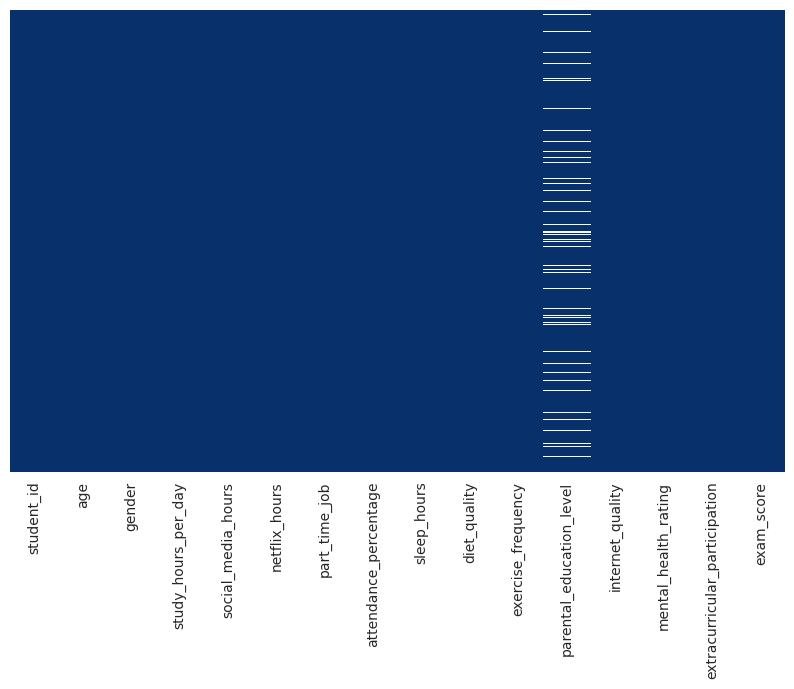

In [ ]:
plt.figure(figsize=(10,6))
sns.heatmap(data.isnull(), cmap='Blues_r', cbar=False, yticklabels=False)
plt.show()

In [ ]:
data['parental_education_level'] = data['parental_education_level'].fillna(data['parental_education_level'].mode()[0])
data['parental_education_level'].value_counts(dropna=False)

,count
parental_education_level,
High School,483
Bachelor,350
Master,167


## **Correlación entre las variables**

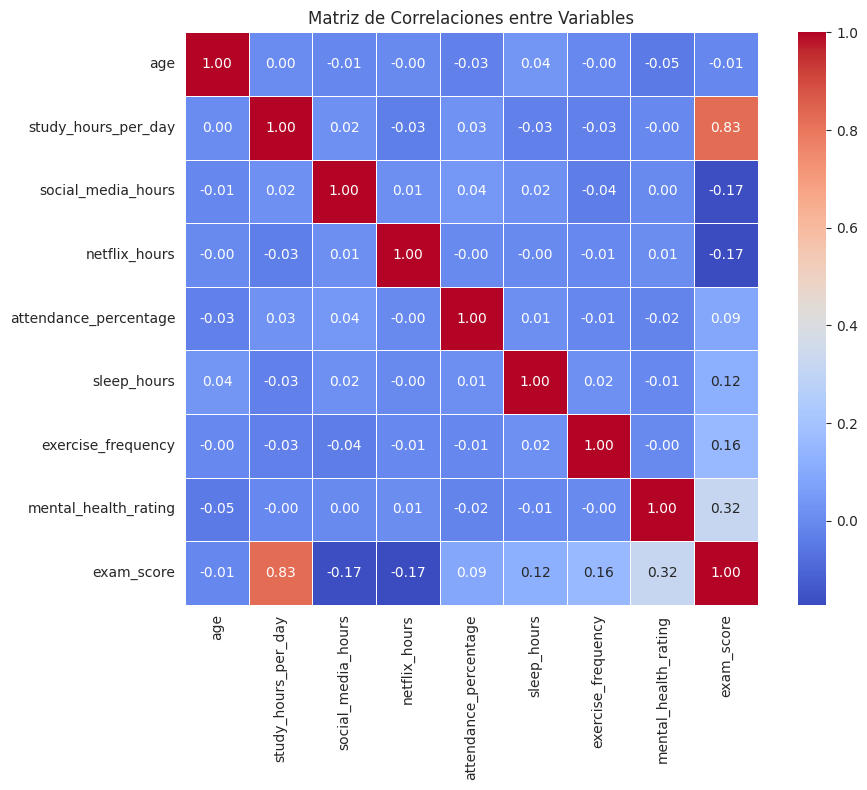

In [ ]:
selected_columns = ['age', 'study_hours_per_day', 'social_media_hours',
                   'netflix_hours', 'attendance_percentage', 'sleep_hours',
                   'exercise_frequency', 'mental_health_rating', 'exam_score']

data_selected = data[selected_columns]
correlation_matrix = data_selected.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5, square=True)

plt.title('Matriz de Correlaciones entre Variables')
plt.tight_layout()
plt.show()

## **Analisis exploratorio**

## **Cantidad de datos por género**

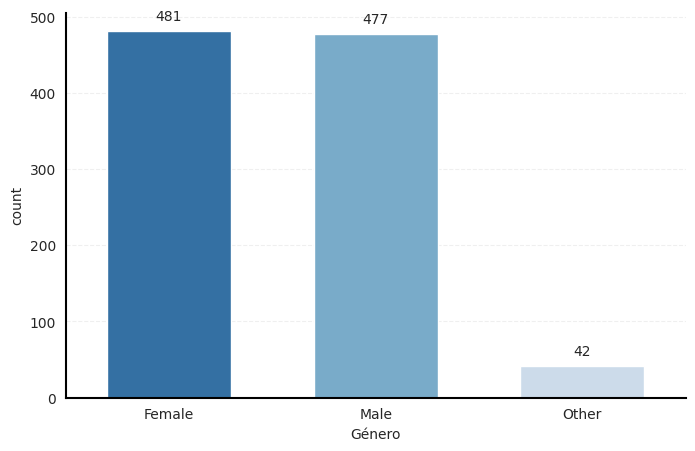

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='gender', palette='Blues_r',width=0.6)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)         # Asegura que estén visibles
    spine.set_linewidth(1.5)        # Grosor del borde
    spine.set_edgecolor('black')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posición x centrada
        height + 10,                        # un poco arriba de la barra
        f'{int(height)}',                   # valor como texto entero
        ha='center', va='bottom', fontsize=10
    )

plt.xlabel('Género')
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

## **Horas de estudio vs puntacion del examen**

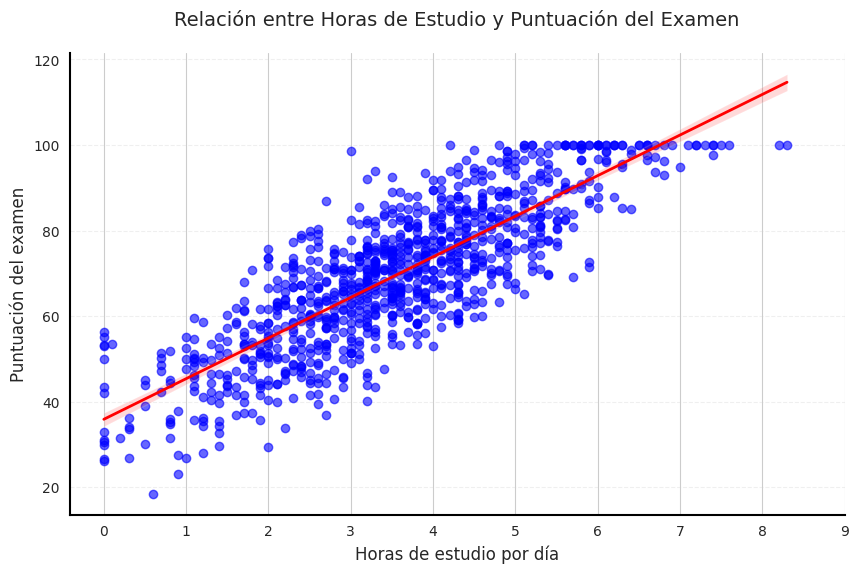

In [ ]:
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)         # Asegura que estén visibles
    spine.set_linewidth(1.5)        # Grosor del borde
    spine.set_edgecolor('black')

sns.regplot(
    data,
    x='study_hours_per_day',
    y='exam_score',
    scatter_kws={'alpha': 0.6, 'color': 'blue'},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Relación entre Horas de Estudio y Puntuación del Examen", fontsize=14, pad=20)
plt.xlabel("Horas de estudio por día", fontsize=12)
plt.ylabel("Puntuación del examen", fontsize=12)
plt.xticks(np.arange(0, data['study_hours_per_day'].max() + 1, 1))

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

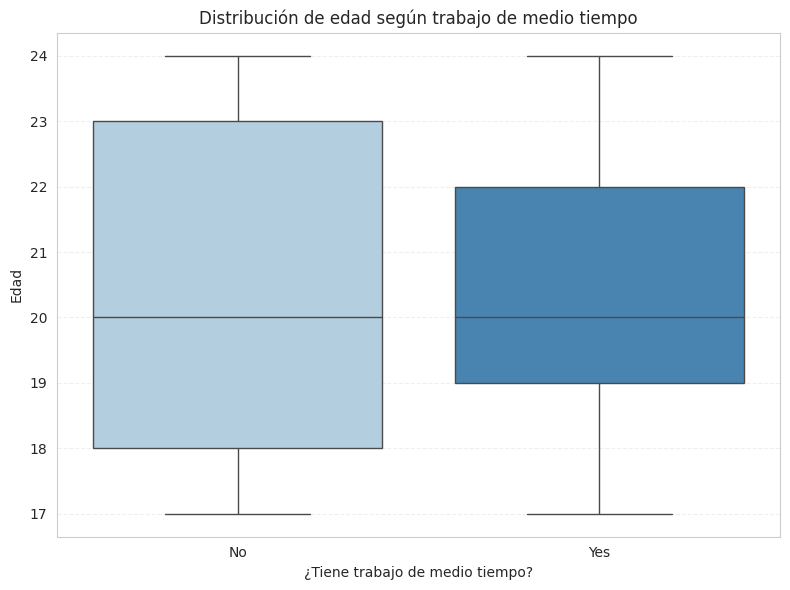

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(data=data, x='part_time_job', y='age', palette='Blues')

plt.title('Distribución de edad según trabajo de medio tiempo')
plt.xlabel('¿Tiene trabajo de medio tiempo?')
plt.ylabel('Edad')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## **Relación entre Salud Mental, Examen y Horas de Estudio**

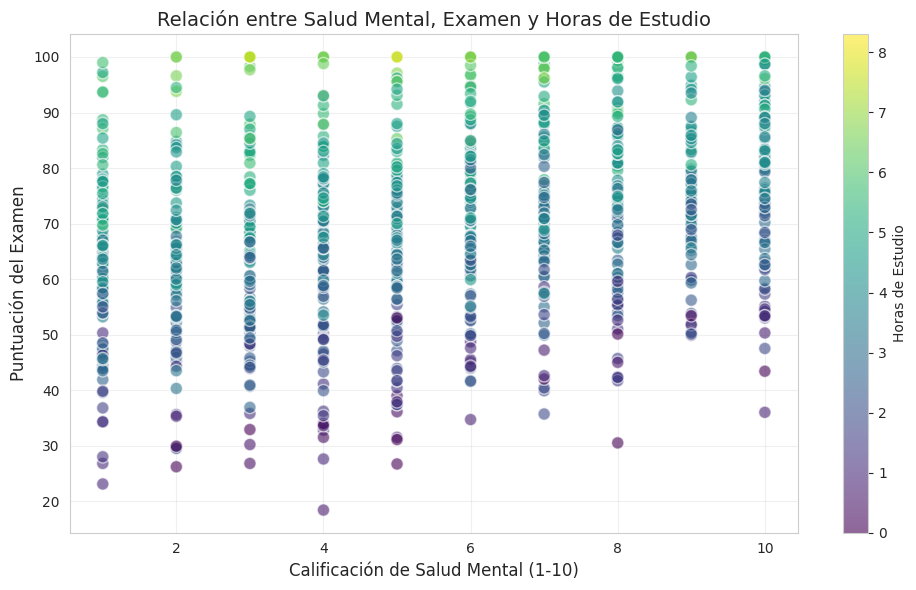

In [ ]:
plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    data['mental_health_rating'],
    data['exam_score'],
    c = data['study_hours_per_day'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='w',
    s=80
)

plt.title("Relación entre Salud Mental, Examen y Horas de Estudio", fontsize=14)
plt.xlabel("Calificación de Salud Mental (1-10)", fontsize=12)
plt.ylabel("Puntuación del Examen", fontsize=12)
plt.colorbar(scatter, label='Horas de Estudio')
plt.grid(alpha=0.3)
plt.tight_layout()


plt.show()


## **Rendimiento vs Horas de sueño**




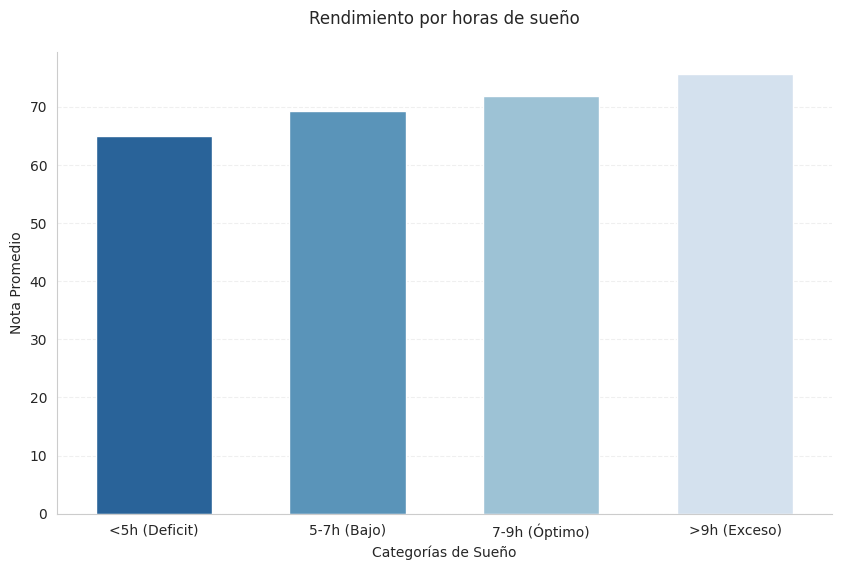

In [ ]:

bins = [0, 5, 7, 9, 24]
labels = ['<5h (Deficit)', '5-7h (Bajo)', '7-9h (Óptimo)', '>9h (Exceso)']

plt.figure(figsize=(10, 6))
sns.barplot(
    data=data,
    x=pd.cut(data['sleep_hours'], bins=bins, labels=labels),
    y='exam_score',
    palette='Blues_r',
    errorbar=None,
    width=0.6,
    order=labels
)

plt.title('Rendimiento por horas de sueño', pad=20)
plt.xlabel('Categorías de Sueño')
plt.ylabel('Nota Promedio')
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

## **Estudiantes con puntajes menores o iguales a 30 (horas de estudio, redes sociales, netflix, sueño**

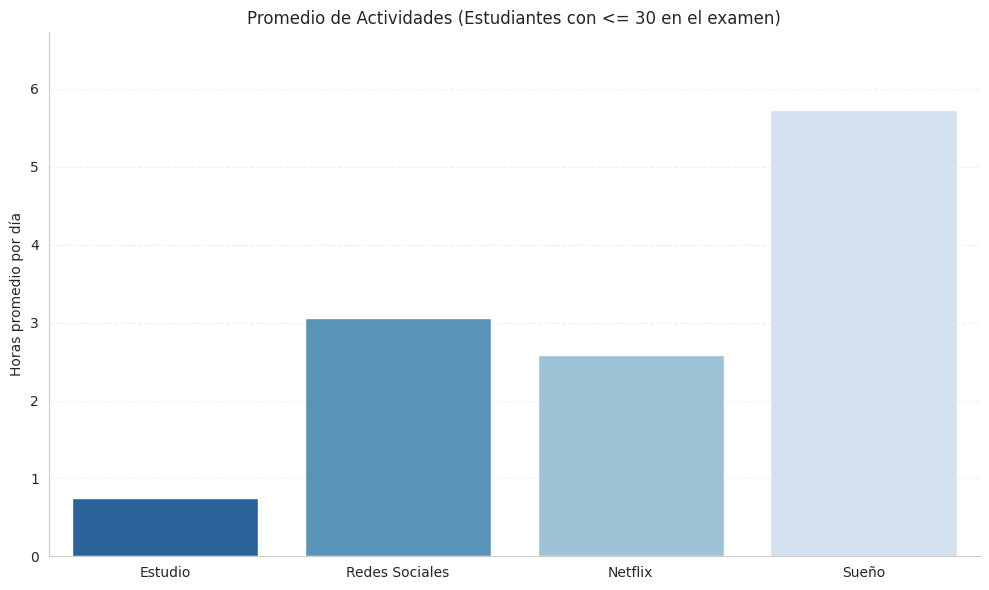

In [ ]:
# Filtrar estudiantes con puntaje menor o igual a 30
high_score_data = data[data['exam_score'] <= 30]

# Calcular promedios de las variables deseadas
avg_study = high_score_data['study_hours_per_day'].mean()
avg_social = high_score_data['social_media_hours'].mean()
avg_netflix = high_score_data['netflix_hours'].mean()
avg_sleep = high_score_data['sleep_hours'].mean()

# Crear DataFrame para la gráfica
avg_df = pd.DataFrame({
    'Actividad': ['Estudio', 'Redes Sociales', 'Netflix', 'Sueño'],
    'Horas Promedio': [avg_study, avg_social, avg_netflix, avg_sleep]
})

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(
    data=avg_df,
    x='Actividad',
    y='Horas Promedio',
    palette='Blues_r'
)

plt.title("Promedio de Actividades (Estudiantes con <= 30 en el examen)")
plt.ylabel("Horas promedio por día")
plt.xlabel("")
plt.ylim(0, avg_df['Horas Promedio'].max() + 1)
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## **Promedio del puntaje de salud mental de los estudiantes con puntajes <=30**

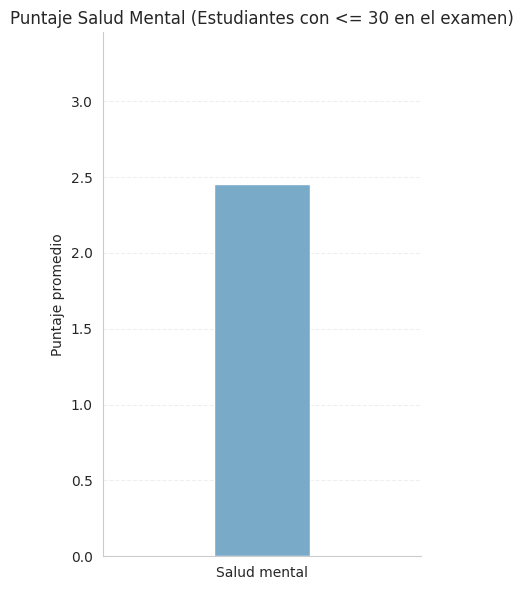

In [ ]:
# Filtrar estudiantes con puntaje menor o igual a 30
high_score_data = data[data['exam_score'] <= 30]

# Calcular promedios de las variables deseadas
avg_mental = high_score_data['mental_health_rating'].mean()

# Crear DataFrame para la gráfica
avg_df = pd.DataFrame({
    'Actividad': ['Salud mental'],
    'Horas Promedio': [avg_mental]
})

# Graficar
plt.figure(figsize=(4, 6))
sns.barplot(
    data=avg_df,
    x='Actividad',
    y='Horas Promedio',
    palette='Blues_r',
    width=0.3
)

plt.title("Puntaje Salud Mental (Estudiantes con <= 30 en el examen)")
plt.ylabel("Puntaje promedio")
plt.xlabel("")
plt.ylim(0, avg_df['Horas Promedio'].max() + 1)
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## **Estudiantes con puntajes menores o iguales a 50 (horas de estudio, redes sociales, netflix, sueño**

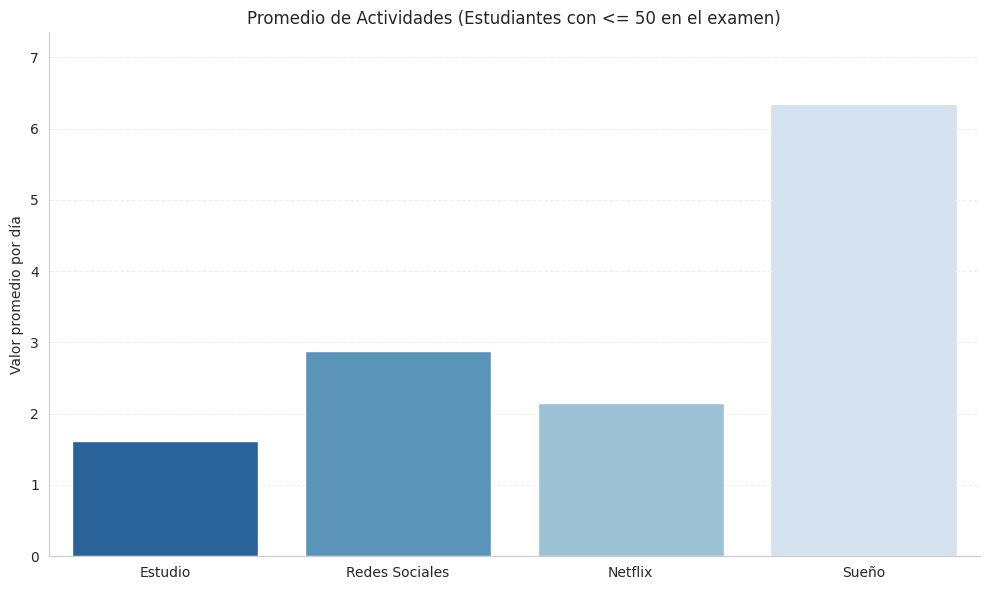

In [ ]:
# Filtrar estudiantes con puntaje menor o igual a 50
high_score_data = data[data['exam_score'] <= 50]

# Calcular promedios de las variables deseadas
avg_study = high_score_data['study_hours_per_day'].mean()
avg_social = high_score_data['social_media_hours'].mean()
avg_netflix = high_score_data['netflix_hours'].mean()
avg_sleep = high_score_data['sleep_hours'].mean()

# Crear DataFrame para la gráfica
avg_df = pd.DataFrame({
    'Actividad': ['Estudio', 'Redes Sociales', 'Netflix', 'Sueño'],
    'Horas Promedio': [avg_study, avg_social, avg_netflix, avg_sleep]
})

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(
    data=avg_df,
    x='Actividad',
    y='Horas Promedio',
    palette='Blues_r'
)

plt.title("Promedio de Actividades (Estudiantes con <= 50 en el examen)")
plt.ylabel("Valor promedio por día")
plt.xlabel("")
plt.ylim(0, avg_df['Horas Promedio'].max() + 1)
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## **Promedio del puntaje de salud mental de los estudiantes con puntajes <=50**

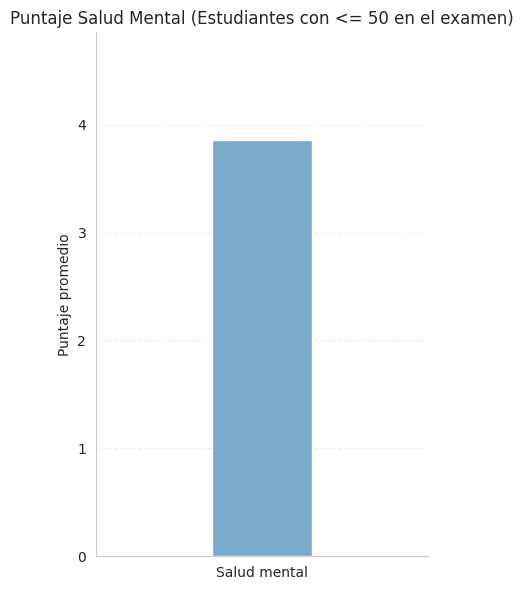

In [ ]:
# Filtrar estudiantes con puntaje menor o igual a 50
high_score_data = data[data['exam_score'] <= 50]

# Calcular promedios de las variables deseadas
avg_mental = high_score_data['mental_health_rating'].mean()

# Crear DataFrame para la gráfica
avg_df = pd.DataFrame({
    'Actividad': ['Salud mental'],
    'Horas Promedio': [avg_mental]
})

# Graficar
plt.figure(figsize=(4, 6))
sns.barplot(
    data=avg_df,
    x='Actividad',
    y='Horas Promedio',
    palette='Blues_r',
    width=0.3
)

plt.title("Puntaje Salud Mental (Estudiantes con <= 50 en el examen)")
plt.ylabel("Puntaje promedio")
plt.xlabel("")
plt.ylim(0, avg_df['Horas Promedio'].max() + 1)
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## **Estudiantes con puntajes mayores o iguales a 80 (horas de estudio, redes sociales, netflix, sueño**

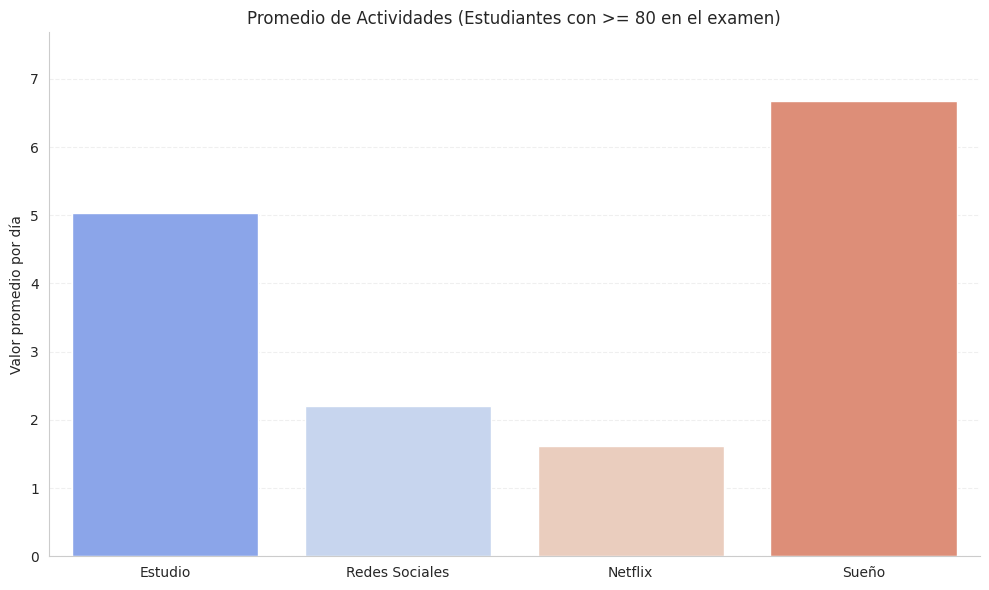

In [ ]:
# Filtrar estudiantes con puntaje mayor o igual a 80
high_score_data = data[data['exam_score'] >= 80]

# Calcular promedios de las variables deseadas
avg_study = high_score_data['study_hours_per_day'].mean()
avg_social = high_score_data['social_media_hours'].mean()
avg_netflix = high_score_data['netflix_hours'].mean()
avg_sleep = high_score_data['sleep_hours'].mean()

# Crear DataFrame para la gráfica
avg_df = pd.DataFrame({
    'Actividad': ['Estudio', 'Redes Sociales', 'Netflix', 'Sueño'],
    'Horas Promedio': [avg_study, avg_social, avg_netflix, avg_sleep]
})

# Graficar
plt.figure(figsize=(10, 6))
sns.barplot(
    data=avg_df,
    x='Actividad',
    y='Horas Promedio',
    palette='coolwarm'
)

plt.title("Promedio de Actividades (Estudiantes con >= 80 en el examen)")
plt.ylabel("Valor promedio por día")
plt.xlabel("")
plt.ylim(0, avg_df['Horas Promedio'].max() + 1)
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## **Promedio del puntaje de salud mental de los estudiantes con puntajes >= 80**

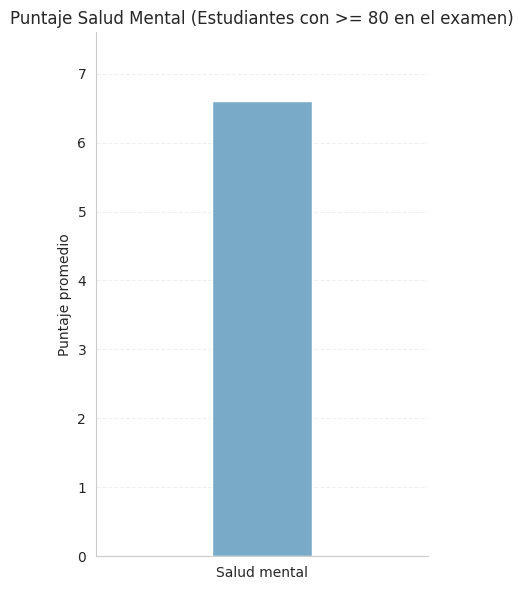

In [ ]:
# Filtrar estudiantes con puntaje mayor o igual a 80
high_score_data = data[data['exam_score'] >= 80]

# Calcular promedios de las variables deseadas
avg_mental = high_score_data['mental_health_rating'].mean()

# Crear DataFrame para la gráfica
avg_df = pd.DataFrame({
    'Actividad': ['Salud mental'],
    'Horas Promedio': [avg_mental]
})

# Graficar
plt.figure(figsize=(4, 6))
sns.barplot(
    data=avg_df,
    x='Actividad',
    y='Horas Promedio',
    palette='Blues_r',
    width=0.3
)

plt.title("Puntaje Salud Mental (Estudiantes con >= 80 en el examen)")
plt.ylabel("Puntaje promedio")
plt.xlabel("")
plt.ylim(0, avg_df['Horas Promedio'].max() + 1)
sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## **Promedio de horas de estudio por género**

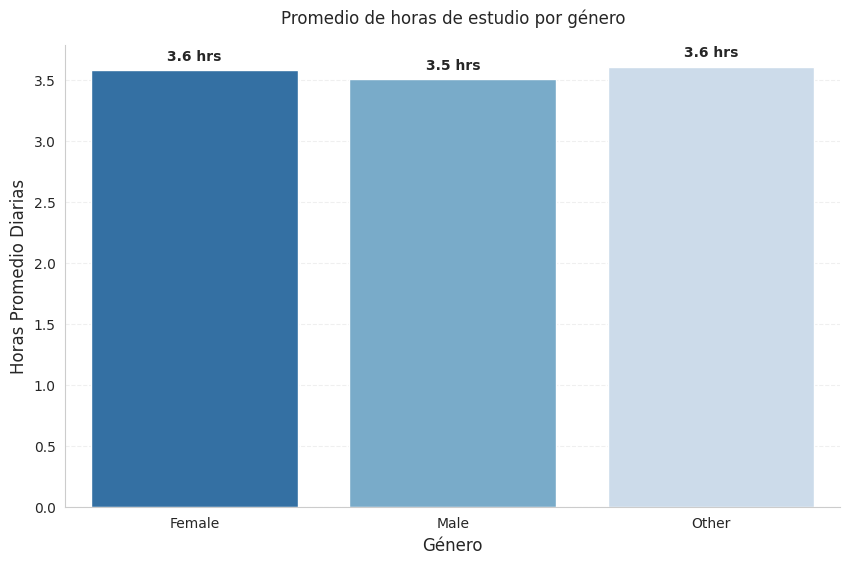

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(data, x='gender', y='study_hours_per_day',
                 estimator='mean', ci=None, palette="Blues_r")

plt.title("Promedio de horas de estudio por género", pad=15)
plt.xlabel("Género", fontsize=12)
plt.ylabel("Horas Promedio Diarias", fontsize=12)

for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f} hrs",
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 10),
                textcoords='offset points', fontweight='bold')

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

## **Horas de studio vs Puntaje del examen en base al uso de redes sociales**

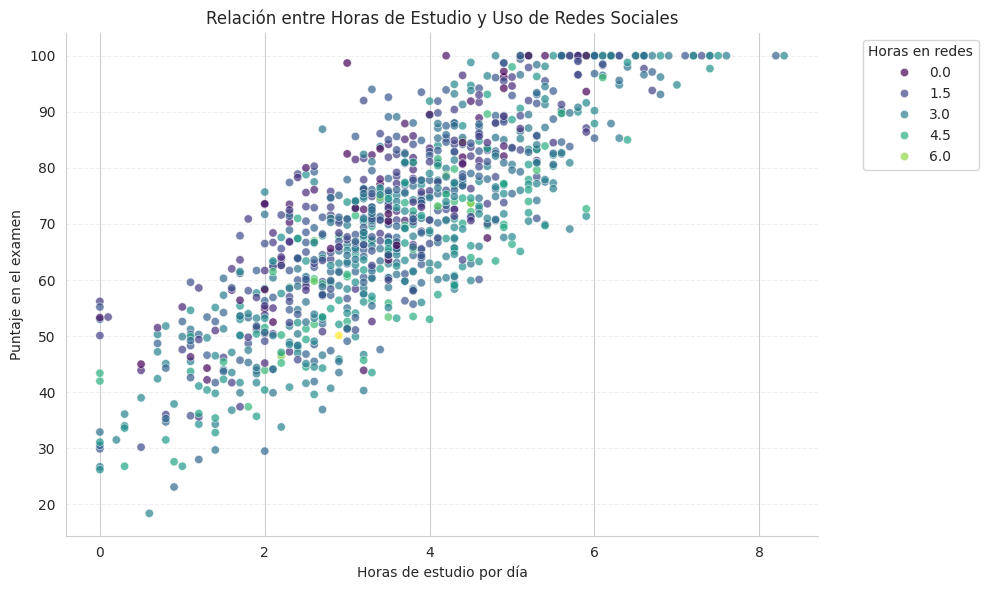

In [ ]:
plt.figure(figsize=(10, 6))

scatter = sns.scatterplot(
    data,
    x='study_hours_per_day',
    y='exam_score',
    hue='social_media_hours',
    palette='viridis',
    alpha=0.7
)

plt.title("Relación entre Horas de Estudio y Uso de Redes Sociales")
plt.xlabel("Horas de estudio por día")
plt.ylabel("Puntaje en el examen")
plt.legend(title='Horas en redes', bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()

plt.show()

## **Valores atípicos**

## **Visualización**

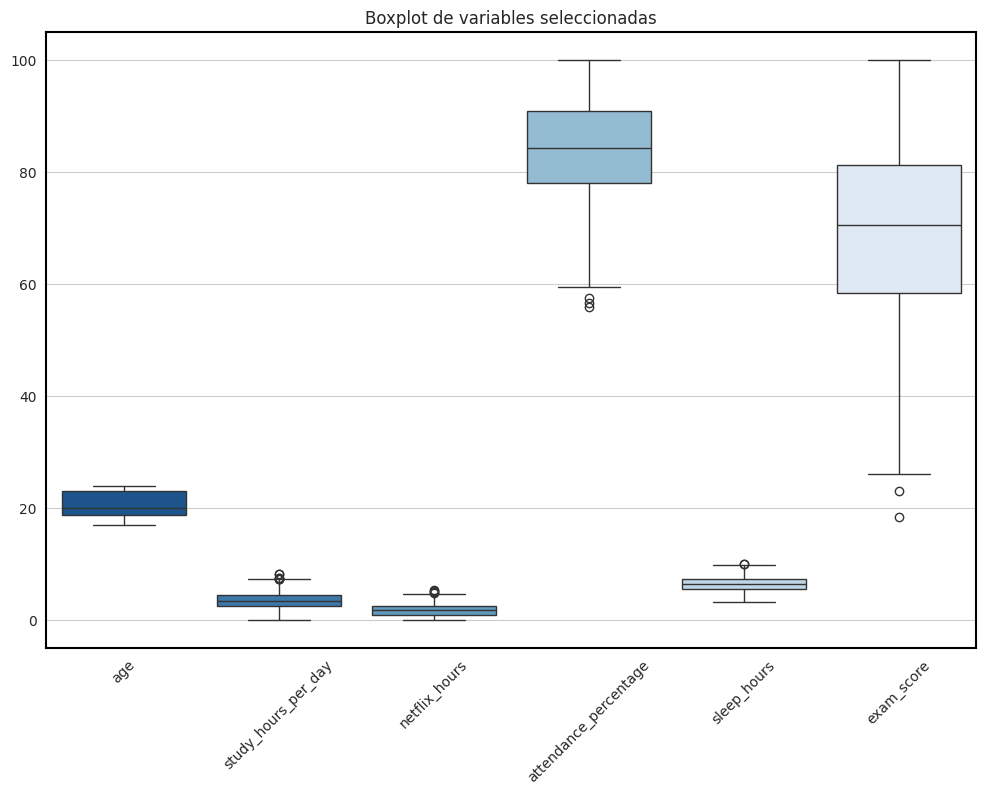

In [ ]:
variables = [
    'age',
    'study_hours_per_day',
    'netflix_hours',
    'attendance_percentage',
    'sleep_hours',
    'exam_score'
]

plt.figure(figsize=(12, 8))
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)         # Asegura que estén visibles
    spine.set_linewidth(1.5)        # Grosor del borde
    spine.set_edgecolor('black')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posición x centrada
        height + 10,                        # un poco arriba de la barra
        f'{int(height)}',                   # valor como texto entero
        ha='center', va='bottom', fontsize=10
    )

sns.boxplot(data=data[variables], palette='Blues_r')
plt.xticks(rotation=45)
plt.title('Boxplot de variables seleccionadas')
plt.show()

## **Eliminación de valores atípicos**

In [ ]:
variables = [
    'study_hours_per_day',
    'social_media_hours',
    'netflix_hours',
    'attendance_percentage',
    'sleep_hours',
    'exam_score',
]

for var in variables:
    Q1, Q3 = data[var].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    print(f"{var}: límites [{lim_inf}, {lim_sup}]")
    data = data[(data[var] >= lim_inf) & (data[var] <= lim_sup)]

study_hours_per_day: límites [-0.24999999999999956, 7.35]
social_media_hours: límites [-0.7, 5.699999999999999]
netflix_hours: límites [-1.25, 4.75]
attendance_percentage: límites [58.400000000000006, 110.4]
sleep_hours: límites [3.0499999999999994, 9.85]
exam_score: límites [24.499999999999993, 114.9]


## **Transformación de variables categóricas**

In [ ]:
cat_cols = ['gender','part_time_job','diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']
encoder = OneHotEncoder(sparse_output=False, drop='first', handle_unknown='ignore')
encoded = encoder.fit_transform(data[cat_cols])
encoded_cols = encoder.get_feature_names_out(cat_cols)
encoded_df = pd.DataFrame(encoded, columns=encoded_cols)
data = data.reset_index(drop=True).join(encoded_df)
data = data.drop(columns=cat_cols)
data.head()

,student_id,age,study_hours_per_day,social_media_hours,netflix_hours,attendance_percentage,sleep_hours,exercise_frequency,mental_health_rating,exam_score,gender_Male,gender_Other,part_time_job_Yes,diet_quality_Good,diet_quality_Poor,parental_education_level_High School,parental_education_level_Master,internet_quality_Good,internet_quality_Poor,extracurricular_participation_Yes
0,S1000,23,0.0,1.2,1.1,85.0,8.0,6,8,56.2,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,S1001,20,6.9,2.8,2.3,97.3,4.6,6,8,100.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
2,S1002,21,1.4,3.1,1.3,94.8,8.0,1,1,34.3,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0
3,S1003,23,1.0,3.9,1.0,71.0,9.2,4,1,26.8,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0
4,S1004,19,5.0,4.4,0.5,90.9,4.9,3,1,66.4,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0


## **7. Separación de variables independientes y dependientes**

Eliminamos la columna student_id

In [ ]:
# los ids son diferentes todos, la maquina busca patrones así que este valor no importa
data = data.drop(columns=['student_id'])

In [ ]:
X = data.drop(columns=['exam_score'])
y = data['exam_score']

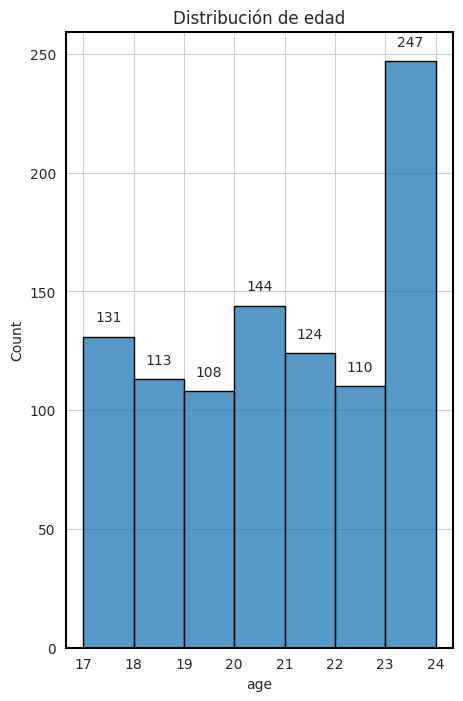

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 8))
sns.histplot(
    data=data,
    x='age',
    kde=False,
    binwidth=1,  # Fuerza un ancho de barra de 1 unidad (ideal si age son enteros)
    palette='Blues_R',
    edgecolor='black',
    element='bars'  # Asegura barras sólidas sin separación
)


ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)         # Asegura que estén visibles
    spine.set_linewidth(1.5)        # Grosor del borde
    spine.set_edgecolor('black')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posición x centrada
        height + 5,                        # un poco arriba de la barra
        f'{int(height)}',                   # valor como texto entero
        ha='center', va='bottom', fontsize=10
    )

plt.title('Distribución de edad')
plt.xlabel('age')
plt.ylabel('Count')
plt.grid(True)
plt.show()

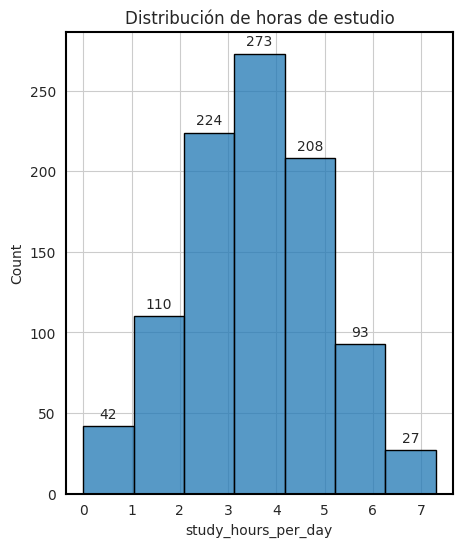

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 6))
sns.histplot(
    data=data,
    x='study_hours_per_day',
    kde=False,
    binwidth=1,  # Fuerza un ancho de barra de 1 unidad (ideal si age son enteros)
    palette='Blues_R',
    edgecolor='black',
    element='bars'  # Asegura barras sólidas sin separación
)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)         # Asegura que estén visibles
    spine.set_linewidth(1.5)        # Grosor del borde
    spine.set_edgecolor('black')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posición x centrada
        height + 3,                        # un poco arriba de la barra
        f'{int(height)}',                   # valor como texto entero
        ha='center', va='bottom', fontsize=10
    )

plt.title('Distribución de horas de estudio')
plt.xlabel('study_hours_per_day')
plt.ylabel('Count')
plt.grid(True)
plt.show()

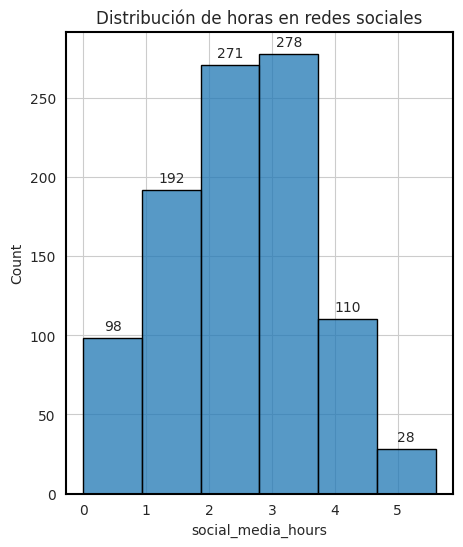

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 6))
sns.histplot(
    data=data,
    x='social_media_hours',
    kde=False,
    binwidth=1,  # Fuerza un ancho de barra de 1 unidad (ideal si age son enteros)
    palette='Blues_R',
    edgecolor='black',
    element='bars'  # Asegura barras sólidas sin separación
)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)         # Asegura que estén visibles
    spine.set_linewidth(1.5)        # Grosor del borde
    spine.set_edgecolor('black')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posición x centrada
        height + 3,                        # un poco arriba de la barra
        f'{int(height)}',                   # valor como texto entero
        ha='center', va='bottom', fontsize=10
    )


plt.title('Distribución de horas en redes sociales')
plt.xlabel('social_media_hours')
plt.ylabel('Count')
plt.grid(True)
plt.show()

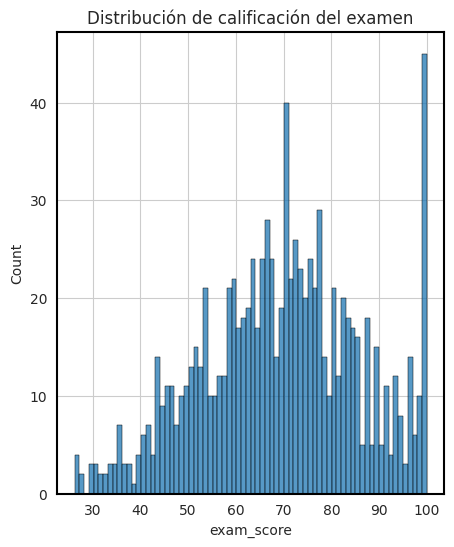

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 6))
sns.histplot(
    data=data,
    x='exam_score',
    kde=False,
    binwidth=1,  # Fuerza un ancho de barra de 1 unidad (ideal si age son enteros)
    palette='Blues_R',
    edgecolor='black',
    element='bars'  # Asegura barras sólidas sin separación
)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)         # Asegura que estén visibles
    spine.set_linewidth(1.5)        # Grosor del borde
    spine.set_edgecolor('black')


plt.title('Distribución de calificación del examen')
plt.xlabel('exam_score')
plt.ylabel('Count')
plt.grid(True)
plt.show()

## 8. **Estandarización de variables**

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

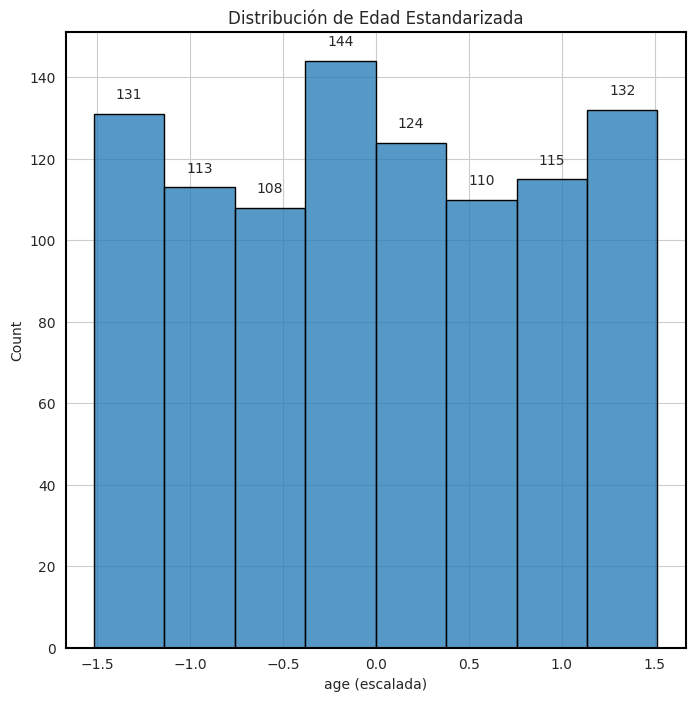

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data['age_scaled'] = scaler.fit_transform(data[['age']])  # Importante: doble corchete

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
sns.histplot(
    data=data,
    x='age_scaled',
    kde=False,
    binwidth=0.4,  # Ajusta según lo que quieras ver
    palette='Blues_R',
    edgecolor='black',
    element='bars'
)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)         # Asegura que estén visibles
    spine.set_linewidth(1.5)        # Grosor del borde
    spine.set_edgecolor('black')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posición x centrada
        height + 3,                        # un poco arriba de la barra
        f'{int(height)}',                   # valor como texto entero
        ha='center', va='bottom', fontsize=10
    )

plt.title('Distribución de Edad Estandarizada')
plt.xlabel('age (escalada)')
plt.ylabel('Count')
plt.grid(True)
plt.show()


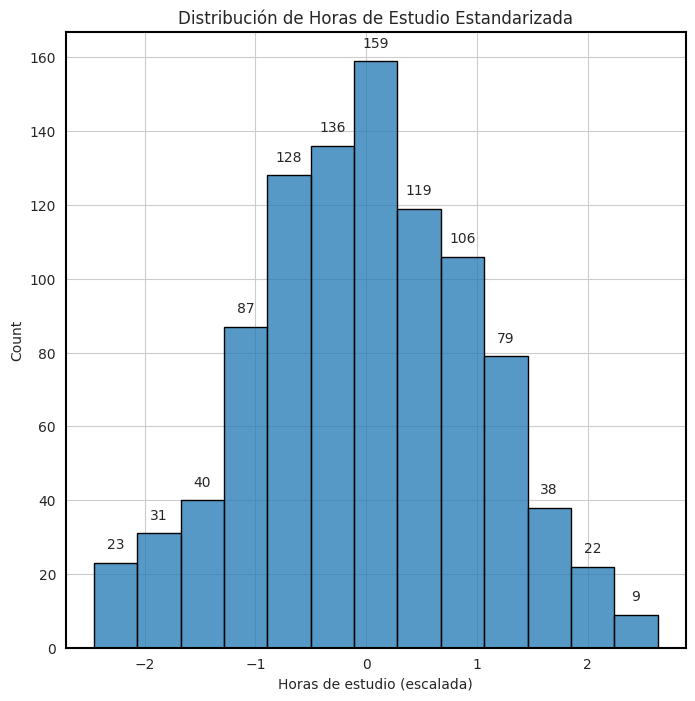

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data['study_hours_per_day'] = scaler.fit_transform(data[['study_hours_per_day']])  # Importante: doble corchete

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
sns.histplot(
    data=data,
    x='study_hours_per_day',
    kde=False,
    binwidth=0.4,  # Ajusta según lo que quieras ver
    palette='Blues_R',
    edgecolor='black',
    element='bars'
)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)         # Asegura que estén visibles
    spine.set_linewidth(1.5)        # Grosor del borde
    spine.set_edgecolor('black')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posición x centrada
        height + 3,                        # un poco arriba de la barra
        f'{int(height)}',                   # valor como texto entero
        ha='center', va='bottom', fontsize=10
    )

plt.title('Distribución de Horas de Estudio Estandarizada')
plt.xlabel('Horas de estudio (escalada)')
plt.ylabel('Count')
plt.grid(True)
plt.show()

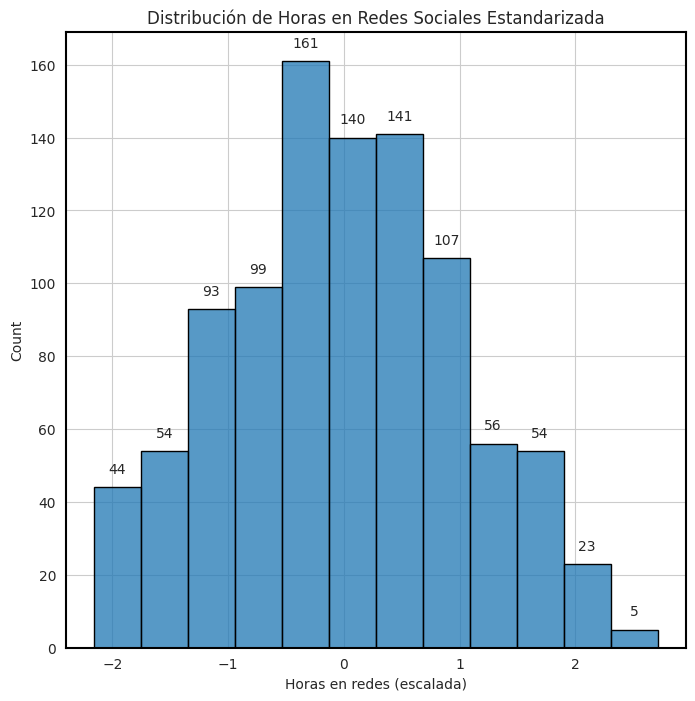

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data['social_media_hours'] = scaler.fit_transform(data[['social_media_hours']])  # Importante: doble corchete

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
sns.histplot(
    data=data,
    x='social_media_hours',
    kde=False,
    binwidth=0.4,  # Ajusta según lo que quieras ver
    palette='Blues_R',
    edgecolor='black',
    element='bars'
)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)         # Asegura que estén visibles
    spine.set_linewidth(1.5)        # Grosor del borde
    spine.set_edgecolor('black')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posición x centrada
        height + 3,                        # un poco arriba de la barra
        f'{int(height)}',                   # valor como texto entero
        ha='center', va='bottom', fontsize=10
    )

plt.title('Distribución de Horas en Redes Sociales Estandarizada')
plt.xlabel('Horas en redes (escalada)')
plt.ylabel('Count')
plt.grid(True)
plt.show()

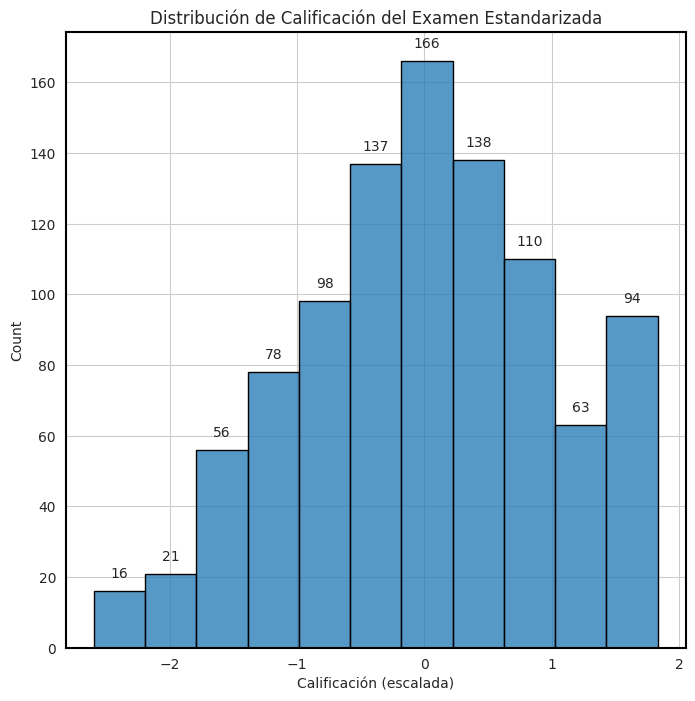

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
data['exam_score'] = scaler.fit_transform(data[['exam_score']])  # Importante: doble corchete

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))
sns.histplot(
    data=data,
    x='exam_score',
    kde=False,
    binwidth=0.4,  # Ajusta según lo que quieras ver
    palette='Blues_R',
    edgecolor='black',
    element='bars'
)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)         # Asegura que estén visibles
    spine.set_linewidth(1.5)        # Grosor del borde
    spine.set_edgecolor('black')

for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # posición x centrada
        height + 3,                        # un poco arriba de la barra
        f'{int(height)}',                   # valor como texto entero
        ha='center', va='bottom', fontsize=10
    )

plt.title('Distribución de Calificación del Examen Estandarizada')
plt.xlabel('Calificación (escalada)')
plt.ylabel('Count')
plt.grid(True)
plt.show()

## **9. Separación en entrenamiento y prueba**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## **10. Entrenamiento y evaluación de modelos**

### **A) Linear gradient**

In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
print('Linear Regression MSE:', mean_squared_error(y_test, y_pred_lr))
print('Linear Regression R2:', r2_score(y_test, y_pred_lr))

### **B) Random Forest**

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [2, 5, 10]
}

#Base
rf = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    refit='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Resultados
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print('-----------------------------')

# Evaluamos sobre los datos de prueba
y_pred_rforest = grid_search.predict(X_test)
print("Random Forest MSE:", mean_squared_error(y_test, y_pred_rforest))
print("Random Forest R2:", r2_score(y_test, y_pred_rforest))

### **C) Gradient Boosting**

In [ ]:
##Base
gb = GradientBoostingRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 150, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5]
}

grid_search = GridSearchCV(
    estimator=gb,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X_train, y_train)

# Resultados
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)
print('-----------------------------')

# Evaluamos sobre los datos de prueba
y_pred_gboosting = grid_search.predict(X_test)
print("Gradient Boosting MSE:", mean_squared_error(y_test, y_pred_gboosting))
print("Gradient Boosting R2:", r2_score(y_test, y_pred_gboosting))

## **D) MLP Regressor**

In [ ]:
mlp = MLPRegressor(max_iter=2000, early_stopping=True)

# Hiperparámetros a probar
param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (100, 50)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.005, 0.01],
    'solver': ['adam', 'sgd']
}

# Grid search con validación cruzada
grid = GridSearchCV(
    mlp, param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1)

# Entrenamiento
grid.fit(X_train, y_train)

# Resultados
print("Mejores hiperparámetros encontrados:")
print(grid.best_params_)
print('-----------------------------')

# Evaluamos sobre los datos de prueba
y_pred_mlp = grid.predict(X_test)
print("ML MSE:", mean_squared_error(y_test, y_pred_mlp))
print("ML R2:", r2_score(y_test, y_pred_mlp))

## 11. Comparación de modelos

In [ ]:
models = ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'MLP']
mse = [mean_squared_error(y_test, y_pred_lr), mean_squared_error(y_test, y_pred_rforest), mean_squared_error(y_test, y_pred_gboosting), mean_squared_error(y_test, y_pred_mlp)]
r2 = [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rforest), r2_score(y_test, y_pred_gboosting), r2_score(y_test, y_pred_mlp)]


plt.figure(figsize=(10,4))

# Gráfico de MSE
plt.subplot(1,2,1)
plt.bar(models, mse)
for i, v in enumerate(mse):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom')
plt.title('MSE por modelo')
plt.xticks(rotation=15)

# Gráfico de R2
plt.subplot(1,2,2)
plt.bar(models, r2)
for i, v in enumerate(r2):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center', va='bottom')
    plt.xticks(rotation=15)
plt.title('R2 por modelo')

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos (Regresión Lineal)')
plt.title('Valores Reales vs. Predichos (Regresión Lineal)')
plt.grid(True)
plt.show()

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_mlp, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos (Regresión Lineal)')
plt.title('Valores Reales vs. Predichos (Regresión Lineal)')
plt.grid(True)
plt.show()